In [1]:
"""
cpt.ipynb

Character-per-token (CPT) "price" distributions and provider margin
distributions from generation outputs in outputs/cpt/, across models,
temperatures, top-p values, and languages.

Conventions
-----------
- Short model names (L1B, L3B, G1B, G4B, M8B) -> see ``MODEL_INFO``.
- Pickle inputs are read from ``CPT_DIR``.
- Figures are written under ``FIGURES_DIR``.
"""

%matplotlib inline

import os
import sys
import pickle

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer

# Resolve project paths from the notebook's location: <work>/notebooks/...
WORK_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
CPT_DIR = os.path.join(WORK_DIR, "outputs", "cpt")
FIGURES_DIR = os.path.join(WORK_DIR, "figures")

# Make src/ importable so we can use the project's plotting helpers.
sys.path.insert(0, os.path.join(WORK_DIR, "src"))
import utils  # noqa: E402

# Short name -> (filename stem used in outputs/cpt/, HuggingFace model id).
MODEL_INFO = {
    "L1B": ("Llama-3.2-1B-Instruct",        "meta-llama/Llama-3.2-1B-Instruct"),
    "L3B": ("Llama-3.2-3B-Instruct",        "meta-llama/Llama-3.2-3B-Instruct"),
    "G1B": ("Gemma-3-1b-it",                "google/gemma-3-1b-it"),
    "G4B": ("Gemma-3-4b-it",                "google/gemma-3-4b-it"),
    "M8B": ("Ministral-8B-Instruct-2410",   "mistralai/Ministral-8B-Instruct-2410"),
}

# Approximate language proportions used to weight per-language
# distributions into a single "joint" distribution.
LANGUAGE_PROPORTIONS = {
    "english": 0.911,
    "spanish": 0.04,
    "russian": 0.04,
    "chinese": 0.07,
}
LANGUAGES = ["english", "spanish", "russian", "chinese"]


In [ ]:
# Sanity check: load one factual_model file for L1B at T=1.0, top-p=1.0,
# and print summary CPT statistics.

short = "L1B"
temperature = 1.0
top_p = 1.0
model_str, hf_id = MODEL_INFO[short]

tokenizer = AutoTokenizer.from_pretrained(hf_id)
sanity_path = os.path.join(
    CPT_DIR,
    f"factual_model{model_str}_p{top_p}_kNone_numprompts400_maxoutlen200_temp{temperature}_idare you .pkl",
)
with open(sanity_path, "rb") as f:
    data = pickle.load(f)

char = [0] * len(data[0]["output"])
tok = [0] * len(data[0]["output"])
for num_seq in range(len(data[0]["output"])):
    for prompt_id in range(len(data)):
        char[num_seq] += len(tokenizer.decode(data[prompt_id]["output"][0]))
        tok[num_seq]  += len(data[prompt_id]["output"][0])

cpts = np.vstack(char) / np.stack(tok)
print(short)
print("Mean CPT      :", np.mean(cpts))
print("Mean 100*cpt-1:", np.mean(100 * cpts - 1, axis=0))
print("CPT std       :", np.std(cpts))


# Character-token price distributions

In [2]:
def get_distribution_per_output(data, tokenizer):
    """Return ``(ratios, mean_cpt)`` where ``mean_cpt`` is the global
    chars/tokens ratio averaged across (prompt, sequence-index), and
    ``ratios`` is each output's ``(chars/tokens) / mean_cpt - 1``.

    Parameters
    ----------
    data : list[dict]
        Output of ``LMSYS_generation``: each entry has a ``"output"`` key
        mapping to a list of token-id sequences.
    tokenizer : transformers tokenizer
    """
    char = [0] * len(data[0]["output"])
    tok = [0] * len(data[0]["output"])

    for num_seq in range(len(data[0]["output"])):
        for prompt_id in range(len(data)):
            char[num_seq] += len(tokenizer.decode(data[prompt_id]["output"][0]))
            tok[num_seq]  += len(data[prompt_id]["output"][0])

    mean_cpt = np.mean(np.vstack(char) / np.stack(tok))

    ratios = []
    for num_seq in range(len(data[0]["output"])):
        for prompt_id in range(len(data)):
            charac = len(tokenizer.decode(data[prompt_id]["output"][0]))
            toke   = len(data[prompt_id]["output"][0])
            if toke == 0 or charac == 0:
                continue
            ratios.append(charac / toke / mean_cpt - 1)

    return ratios, mean_cpt


def get_distribution(data, tokenizer):
    """Like ``get_distribution_per_output`` but ``mean_cpt`` is the mean
    of per-output CPT ratios (pooled across prompts and sequence indices)
    rather than the global chars/tokens ratio."""
    cpts = [0] * len(data[0]["output"])

    for num_seq in range(len(data[0]["output"])):
        for prompt_id in range(len(data)):
            char = len(tokenizer.decode(data[prompt_id]["output"][0]))
            tok  = len(data[prompt_id]["output"][0])
            cpts.append(char / tok)

    mean_cpt = np.mean(cpts)

    ratios = []
    for num_seq in range(len(data[0]["output"])):
        for prompt_id in range(len(data)):
            charac = len(tokenizer.decode(data[prompt_id]["output"][0]))
            toke   = len(data[prompt_id]["output"][0])
            if toke == 0 or charac == 0:
                continue
            ratios.append(charac / toke / mean_cpt - 1)

    return ratios, mean_cpt


def load_factual(short_name, top_p, temperature, language=None, num_prompts=None):
    """Load a ``factual_model*.pkl`` from ``CPT_DIR``.

    Two filename schemes exist in this folder:

    1. English-only ("are you" prompt set), ``language=None``:
       ``factual_model<MS>_p<P>_kNone_numprompts<NP>_maxoutlen200_temp<T>_idare you .pkl``
       Default ``num_prompts=400``.

    2. Multilingual set, ``language`` given:
       ``factual_model<MS>_lan<lang>_p<P>_kNone_numprompts<NP>_maxoutlen200_temp<T>.pkl``
       Default ``num_prompts=500``.
    """
    model_str = MODEL_INFO[short_name][0]
    if language is None:
        np_ = num_prompts if num_prompts is not None else 400
        fname = (f"factual_model{model_str}_p{top_p}_kNone_"
                 f"numprompts{np_}_maxoutlen200_temp{temperature}_idare you .pkl")
    else:
        np_ = num_prompts if num_prompts is not None else 500
        fname = (f"factual_model{model_str}_lan{language}_p{top_p}_kNone_"
                 f"numprompts{np_}_maxoutlen200_temp{temperature}.pkl")
    with open(os.path.join(CPT_DIR, fname), "rb") as f:
        return pickle.load(f)


In [ ]:
# Load tokenizers and the English-only ("are you" prompt set) factual_model
# data for L1B / L3B / G1B / M8B, computing per-output ratio distributions
# for every (top_p, temperature) combination used in the paper.

TOKENIZERS = {
    short: AutoTokenizer.from_pretrained(hf) for short, (_, hf) in MODEL_INFO.items()
}

# Backwards-compatible aliases.
tokenizer_L1 = TOKENIZERS["L1B"]
tokenizer_L3B = TOKENIZERS["L3B"]
tokenizer_G1B = TOKENIZERS["G1B"]
tokenizer_M8B = TOKENIZERS["M8B"]

EN_TOP_PS = [1.0, 0.95, 0.9]
EN_TEMPERATURES = [1.0, 1.15, 1.3]

# data_en[(short, p, T)]   -> pickle data
# ratios_en[(short, p, T)] -> (ratios_list, mean_cpt)
data_en = {}
ratios_en = {}
for short_name in ["L1B", "L3B", "G1B", "M8B"]:
    tok = TOKENIZERS[short_name]
    for p in EN_TOP_PS:
        for T in EN_TEMPERATURES:
            d = load_factual(short_name, p, T)
            data_en[(short_name, p, T)] = d
            ratios_en[(short_name, p, T)] = get_distribution(d, tok)


In [ ]:
# Gemma-3-4B shares its tokenizer with Gemma-3-1B

for p in EN_TOP_PS:
    for T in EN_TEMPERATURES:
        d = load_factual("G4B", p, T)
        data_en[("G4B", p, T)] = d
        ratios_en[("G4B", p, T)] = get_distribution(d, TOKENIZERS["G1B"])


In [ ]:
# Llama-3.2-3B at T=1.3: KDE of price-change ratios for three top-p values,
# with the average 10th percentile drawn as a vertical line.

sns.set_theme(context="paper", style="ticks", font_scale=1)
palette = sns.color_palette("husl", 3)
utils.latexify()  # Computer Modern, with TeX

fig_width, fig_height = utils.get_fig_dim(469, fraction=0.6)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

for p, color in zip([1.0, 0.95, 0.9], [palette[2], palette[1], palette[0]]):
    ratios_list, _ = ratios_en[("L3B", p, 1.3)]
    sns.kdeplot(x=[v * 100 for v in ratios_list], color=color, ax=ax,
                legend=False, fill=False, linewidth=1, alpha=1)

sns.despine(ax=ax)
ax.set_xticks([-75, -50, -25, 0, 25, 50, 75])
ax.set_xticklabels([])
ax.set_xlabel("")
ax.set_ylabel("Probability")

mean_10p = np.mean([
    np.percentile([v * 100 for v in ratios_en[("L3B", p, 1.3)][0]], 10)
    for p in [1.0, 0.95, 0.9]
])
ax.axvline(x=mean_10p, color="black", linestyle="--",
           label="Mean 10% CPT", linewidth=1.5, alpha=0.7)

ax.set_ylim(0, 0.035)
ax.set_xlim(-100, 100)
ax.set_yticks([0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035])

fig.tight_layout()
plt.show()
# fig.savefig(os.path.join(FIGURES_DIR, "price_dist", "ratios_L3B_T13.pdf"), dpi=300)


In [ ]:
def plot_distribution(short_name, temperature, language):
    """KDE of the price-change ratio at top-p in {0.99, 0.95, 0.9} for one
    ``(short_name, temperature, language)``, plus a vertical line at the
    average 10th percentile and another at the mean CPT. Saves to
    ``FIGURES_DIR/price_dist/``.
    """
    tokenizer = TOKENIZERS[short_name]

    data_per_p = {p: load_factual(short_name, p, temperature, language=language)
                  for p in [0.99, 0.95, 0.9]}
    ratios_per_p = {p: get_distribution(data, tokenizer)[0]
                    for p, data in data_per_p.items()}

    sns.set_theme(context="paper", style="ticks", font_scale=1)
    palette = sns.color_palette("husl", 3)
    utils.latexify()
    fig_width, fig_height = utils.get_fig_dim(469, fraction=0.6)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    for p, color in zip([0.99, 0.95, 0.9], [palette[2], palette[1], palette[0]]):
        sns.kdeplot(x=[v * 100 for v in ratios_per_p[p]],
                    color=color, ax=ax, legend=False, fill=False, linewidth=1, alpha=1)

    sns.despine(ax=ax)
    ax.set_xlabel(r"Price change $\%$ ")
    ax.set_ylabel("Probability")

    mean_10p = np.mean([np.percentile([v * 100 for v in ratios_per_p[p]], 10)
                        for p in [0.99, 0.95, 0.9]])
    ax.axvline(x=mean_10p, color="black", linestyle="--",
               label="Mean 10% CPT", linewidth=1.5, alpha=0.7)

    mean_cpt = np.mean([np.mean([v * 100 for v in ratios_per_p[p]])
                        for p in [0.99, 0.95, 0.9]])
    ax.axvline(x=mean_cpt, color="black", linestyle=":",
               label="Mean CPT", linewidth=1.5, alpha=0.7)

    ax.set_ylim(0, 0.055)
    ax.set_xlim(-100, 100)
    ax.set_yticks([0, 0.005, 0.015, 0.025, 0.035, 0.045, 0.055])
    ax.set_xticks([-75, -50, -25, 0, 25, 50, 75])

    if temperature != 1.3:
        ax.set_yticklabels([])
        ax.set_ylabel("")
    if short_name != "M8B":
        ax.set_xticklabels([])
        ax.set_xlabel("")

    fig.tight_layout()
    out_path = os.path.join(FIGURES_DIR, "price_dist",
                            f"ratios_{short_name}_{language}_{temperature}.pdf")
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    fig.savefig(out_path, dpi=300)


for short_name in ["L1B", "L3B", "G1B", "G4B", "M8B"]:
    for temperature in [1.15, 1.3]:
        for language in LANGUAGES:
            print(f"Plotting distribution for {short_name} at temperature {temperature} in {language}")
            plot_distribution(short_name, temperature, language)


In [ ]:
# Load English and Spanish factual_model data for M8B at T=1.0 across the
# three top-p values; consumed by the comparison statistics below.

short_name = "M8B"
temperature = 1.0
tokenizer = TOKENIZERS[short_name]

data_p1     = load_factual(short_name, 0.99, temperature, language="english")
data_p1_es  = load_factual(short_name, 0.99, temperature, language="spanish")
data_p095_es = load_factual(short_name, 0.95, temperature, language="spanish")
data_p090_es = load_factual(short_name, 0.9,  temperature, language="spanish")


In [70]:
# Total tokens vs total characters, English vs Spanish (same model, T=1.0,
# top-p=0.99): a rough check that Spanish outputs use more tokens per
# character than English.

total_tokens_en = sum(len(output) for prompt in data_p1 for output in prompt["output"])
print(f"Total tokens for english data: {total_tokens_en}")

total_tokens_es = sum(len(output) for prompt in data_p1_es for output in prompt["output"])
print(f"Total tokens for spanish data: {total_tokens_es}")

print("Relative difference in tokens between english and spanish data:",
      (total_tokens_es - total_tokens_en) / total_tokens_en)

total_chars_en = sum(len(tokenizer.decode(output))
                     for prompt in data_p1 for output in prompt["output"])
print(f"Total characters for english data: {total_chars_en}")

total_chars_es = sum(len(tokenizer.decode(output))
                     for prompt in data_p1_es for output in prompt["output"])
print(f"Total characters for spanish data: {total_chars_es}")

char_per_token_en = total_chars_en / total_tokens_en
char_per_token_es = total_chars_es / total_tokens_es

print("Relative difference in characters between english and spanish data:",
      char_per_token_en * total_chars_es / total_chars_en / char_per_token_es - 1)


Total tokens for english data: 104713
Total tokens for spanish data: 102613
Relative difference in tokens between english and spanish data:  -0.02005481649842904
Total characters for english data: 518885
Total characters for spanish data: 463062
Relative difference in characters between english and spanish data:  -0.020054816498429107


# Same cpt accroos languages


=== Analysis for L1B ===


Model L1B: Weighted average CPT = 4.9345
Taking 500 samples for english based on proportion 0.9110
Taking 21 samples for spanish based on proportion 0.0400
Taking 21 samples for russian based on proportion 0.0400
Taking 38 samples for chinese based on proportion 0.0700
For model L1B at temperature 1.0, 56.60% of English data shows a price increase.
For model L1B at temperature 1.0, 94.60% of English data shows a price change above -25%.


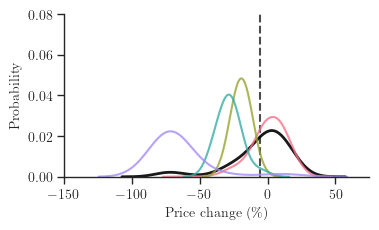


=== Analysis for G1B ===
Model G1B: Weighted average CPT = 5.5292
Taking 500 samples for english based on proportion 0.9110
Taking 21 samples for spanish based on proportion 0.0400
Taking 21 samples for russian based on proportion 0.0400
Taking 38 samples for chinese based on proportion 0.0700
For model G1B at temperature 1.0, 53.40% of English data shows a price increase.
For model G1B at temperature 1.0, 99.00% of English data shows a price change above -25%.


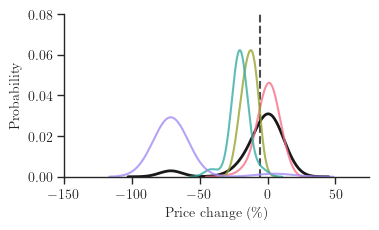


=== Analysis for M8B ===


In [ ]:
def compute_weighted_cpt_via_lang_means_and_plot(short_name, temperature):
    """Per-language price-change KDEs using a weighted CPT computed as
    ``sum(mean_cpt_lang * proportion_lang)``.

    Also plots the joint KDE built from a proportionally-sampled
    multilingual concatenation of the four language datasets. Saves to
    ``FIGURES_DIR/price_dist/``. This is the "v1" version of the weighted
    CPT computation; see ``compute_weighted_cpt_via_concat_and_plot`` for
    the alternative weighting and ultimately preferred plot.
    """
    tokenizer = TOKENIZERS[short_name]

    language_data = {lang: load_factual(short_name, 0.95, temperature, language=lang)
                     for lang in LANGUAGES}
    language_cpts = {lang: get_distribution(language_data[lang], tokenizer)[1]
                     for lang in LANGUAGES}

    weighted_cpt = sum(language_cpts[lang] * LANGUAGE_PROPORTIONS[lang]
                       for lang in LANGUAGE_PROPORTIONS)
    print(f"Model {short_name}: Weighted average CPT = {weighted_cpt:.4f}")

    # Concatenated multilingual dataset, sampled in proportion to English.
    concatenated_data = []
    for lang in LANGUAGES:
        data = language_data[lang]
        proportion = LANGUAGE_PROPORTIONS[lang]
        total_samples = len(data) * len(data[0]["output"])
        samples_to_take = int(total_samples * proportion / LANGUAGE_PROPORTIONS["english"])
        print(f"Taking {samples_to_take} samples for {lang} based on proportion {proportion:.4f}")
        sample_count = 0
        for prompt_data in data:
            for output in prompt_data["output"]:
                if sample_count < samples_to_take:
                    concatenated_data.append({"language": lang, "output": output,
                                              "prompt": prompt_data["prompt"]})
                    sample_count += 1
                else:
                    break
            if sample_count >= samples_to_take:
                break

    sns.set_theme(context="paper", style="ticks", font_scale=1)
    palette = sns.color_palette("husl", 4)
    utils.latexify()
    fig_width, fig_height = utils.get_fig_dim(469, fraction=0.6)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Joint weighted-average KDE (from concatenated dataset).
    all_price_changes = []
    for sample in concatenated_data:
        output = sample["output"]
        if len(output) == 0:
            continue
        chars = len(tokenizer.decode(output))
        tokens = len(output)
        if tokens == 0 or chars == 0:
            continue
        all_price_changes.append((chars / tokens / weighted_cpt - 1) * 100)
    sns.kdeplot(x=all_price_changes, color="black", ax=ax, legend=True, fill=False,
                linewidth=2, alpha=0.9, label="Weighted Avg.", bw_adjust=1.5)
    mean_weighted = np.mean(all_price_changes)
    ax.axvline(x=mean_weighted, color="black", linestyle="--",
               label="Mean Weighted", linewidth=1.5, alpha=0.7)

    # Per-language KDEs (no legend).
    for i, lang in enumerate(LANGUAGES):
        lang_price_changes = []
        for sample in concatenated_data:
            if sample["language"] != lang:
                continue
            output = sample["output"]
            if len(output) == 0:
                continue
            chars = len(tokenizer.decode(output))
            tokens = len(output)
            if tokens == 0 or chars == 0:
                continue
            lang_price_changes.append((chars / tokens / weighted_cpt - 1) * 100)
        if lang_price_changes:
            sns.kdeplot(x=lang_price_changes, color=palette[i], ax=ax, legend=False,
                        fill=False, linewidth=1.5, alpha=0.8, bw_adjust=1.5)

    sns.despine(ax=ax)
    ax.set_xlabel(r"Price change ($\%$)")
    ax.set_ylabel("Probability")
    ax.set_xlim(-150, 75)
    ax.set_ylim(0, 0.08)
    if ax.get_legend():
        ax.get_legend().remove()

    english_changes = [
        ((len(tokenizer.decode(sample["output"])) / len(sample["output"])) / weighted_cpt - 1) * 100
        for sample in concatenated_data
        if sample["language"] == "english" and len(sample["output"]) > 0
    ]
    pct_above_0 = sum(1 for x in english_changes if x > 0) / len(english_changes) * 100
    print(f"For model {short_name} at temperature {temperature}, "
          f"{pct_above_0:.2f}% of English data shows a price increase.")
    pct_above_neg25 = sum(1 for x in english_changes if x > -25) / len(english_changes) * 100
    print(f"For model {short_name} at temperature {temperature}, "
          f"{pct_above_neg25:.2f}% of English data shows a price change above -25%.")

    fig.tight_layout()
    plt.show()
    out_path = os.path.join(FIGURES_DIR, "price_dist",
                            f"multi_languages_{short_name}_{temperature}.pdf")
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    fig.savefig(out_path, dpi=300)
    return weighted_cpt


temperature = 1.0
for short_name in ["L1B", "G1B", "M8B"]:
    print(f"\n=== Analysis for {short_name} ===")
    compute_weighted_cpt_via_lang_means_and_plot(short_name, temperature)


In [ ]:
def compute_weighted_cpt_via_concat_and_plot(short_name, temperature):
    """Per-language price-change KDEs using a weighted CPT computed as
    ``total_chars / total_tokens`` over the multilingual concatenated
    dataset (the "v2" weighting).

    This version draws KDEs only for individual languages and overlays
    each per-language mean; the joint KDE is not plotted (its line was
    commented out in the original notebook). Saves to
    ``FIGURES_DIR/price_dist/`` with the same filename as the v1 version,
    so this overwrites it when both are run.
    """
    tokenizer = TOKENIZERS[short_name]

    language_data = {lang: load_factual(short_name, 0.95, temperature, language=lang)
                     for lang in LANGUAGES}

    # Step 1: build concatenated dataset using LANGUAGE_PROPORTIONS.
    concatenated_data = []
    for lang in LANGUAGES:
        data = language_data[lang]
        proportion = LANGUAGE_PROPORTIONS[lang]
        total_samples = len(data) * len(data[0]["output"])
        samples_to_take = int(total_samples * proportion / LANGUAGE_PROPORTIONS["english"])
        print(f"Taking {samples_to_take} samples for {lang} based on proportion {proportion:.4f}")
        sample_count = 0
        for prompt_data in data:
            for output in prompt_data["output"]:
                if sample_count < samples_to_take:
                    concatenated_data.append({"language": lang, "output": output,
                                              "prompt": prompt_data["prompt"]})
                    sample_count += 1
                else:
                    break
            if sample_count >= samples_to_take:
                break

    # Step 2: weighted CPT directly from total chars / total tokens.
    total_chars, total_tokens = 0, 0
    for sample in concatenated_data:
        output = sample["output"]
        if len(output) == 0:
            continue
        chars = len(tokenizer.decode(output))
        tokens = len(output)
        if tokens == 0 or chars == 0:
            continue
        total_chars += chars
        total_tokens += tokens
    weighted_cpt = total_chars / total_tokens if total_tokens > 0 else 0
    print(f"Model {short_name}: Weighted average CPT (from concatenated dataset) = {weighted_cpt:.4f}")

    # Step 3: per-language KDEs + per-language mean vertical lines.
    sns.set_theme(context="paper", style="ticks", font_scale=1)
    palette = sns.color_palette("husl", 4)
    utils.latexify()
    fig_width, fig_height = utils.get_fig_dim(469, fraction=0.6)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    for i, lang in enumerate(LANGUAGES):
        lang_price_changes = []
        for prompt_data in language_data[lang]:
            for output in prompt_data["output"]:
                if len(output) == 0:
                    continue
                chars = len(tokenizer.decode(output))
                tokens = len(output)
                if tokens == 0 or chars == 0:
                    continue
                lang_price_changes.append((chars / tokens / weighted_cpt - 1) * 100)
        if lang_price_changes:
            sns.kdeplot(x=lang_price_changes, color=palette[i], ax=ax, legend=False,
                        fill=False, linewidth=1.5, alpha=0.8, bw_adjust=1.5)
            mean_lang = np.mean(lang_price_changes)
            ax.axvline(x=mean_lang, color=palette[i], linestyle="--", linewidth=1.5,
                       alpha=0.7, label=f"Mean {lang.capitalize()}")
            print(f"Mean price change for {lang}: {mean_lang:.2f}%")

    sns.despine(ax=ax)
    ax.set_xlabel(r"Price change ($\%$)")
    ax.set_ylabel("Probability")
    ax.set_xlim(-150, 75)
    ax.set_ylim(0, 0.08)
    if ax.get_legend():
        ax.get_legend().remove()

    english_changes = [
        ((len(tokenizer.decode(output)) / len(output)) / weighted_cpt - 1) * 100
        for prompt_data in language_data["english"]
        for output in prompt_data["output"] if len(output) > 0
    ]
    pct_above_0 = sum(1 for x in english_changes if x > 0) / len(english_changes) * 100
    print(f"For model {short_name} at temperature {temperature}, "
          f"{pct_above_0:.2f}% of English data shows a price increase.")
    pct_above_neg25 = sum(1 for x in english_changes if x > -25) / len(english_changes) * 100
    print(f"For model {short_name} at temperature {temperature}, "
          f"{pct_above_neg25:.2f}% of English data shows a price change above -25%.")

    fig.tight_layout()
    plt.show()
    out_path = os.path.join(FIGURES_DIR, "price_dist",
                            f"multi_languages_{short_name}_{temperature}.pdf")
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    fig.savefig(out_path, dpi=300)
    return weighted_cpt


temperature = 1.0
for short_name in ["L1B", "G1B", "M8B"]:
    print(f"\n=== Analysis for {short_name} ===")
    compute_weighted_cpt_via_concat_and_plot(short_name, temperature)


# Margin dist


Model L1B: Weighted average CPT = 4.6726
Using data for language: joint with 580 samples.


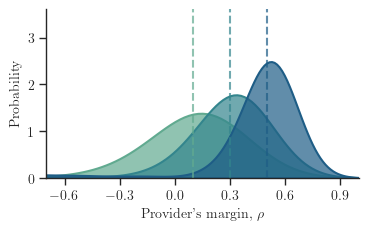

Model M8B: Weighted average CPT = 4.6339
Using data for language: joint with 580 samples.


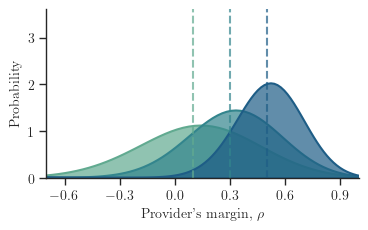

Model G1B: Weighted average CPT = 5.2225
Using data for language: joint with 580 samples.


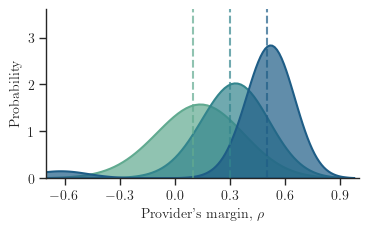

np.float64(5.222500294595484)

In [41]:
def plot_margin_pdf(short_name, temperature,
                    rho_list=[0.1, 0.3, 0.5, 0.7, 0.9],
                    language="joint"):
    """KDE of the provider's margin ``1 - (weighted_cpt / cpt_output) * (1 - rho)``
    for each ``rho`` in ``rho_list``.

    ``language="joint"`` uses the multilingual concatenated dataset
    sampled per ``LANGUAGE_PROPORTIONS``; otherwise the full monolingual
    dataset is used. The reference CPT is always computed from the joint
    dataset (mean of per-output CPTs). Saves to ``FIGURES_DIR/margin_dist/``.
    """
    if isinstance(rho_list, float):
        rho_list = [rho_list]
    tokenizer = TOKENIZERS[short_name]

    language_data = {lang: load_factual(short_name, 0.95, temperature, language=lang)
                     for lang in LANGUAGES}

    concatenated_data = []
    for lang in LANGUAGES:
        data = language_data[lang]
        proportion = LANGUAGE_PROPORTIONS[lang]
        total_samples = len(data) * len(data[0]["output"])
        samples_to_take = int(total_samples * proportion / LANGUAGE_PROPORTIONS["english"])
        sample_count = 0
        for prompt_data in data:
            for output in prompt_data["output"]:
                if sample_count < samples_to_take:
                    concatenated_data.append({"language": lang, "output": output,
                                              "prompt": prompt_data["prompt"]})
                    sample_count += 1
                else:
                    break
            if sample_count >= samples_to_take:
                break

    if language == "joint":
        data_to_use = concatenated_data
    elif language in LANGUAGES:
        data_to_use = [{"output": output}
                       for prompt_data in language_data[language]
                       for output in prompt_data["output"]]
    else:
        raise ValueError(f"Unknown language '{language}'. Choose 'joint' or one of {LANGUAGES}.")

    # Reference CPT: mean of per-output CPT on the joint dataset.
    cpts = []
    for sample in concatenated_data:
        output = sample["output"]
        if len(output) == 0:
            continue
        chars = len(tokenizer.decode(output))
        tokens = len(output)
        if tokens == 0 or chars == 0:
            continue
        cpts.append(chars / tokens)
    weighted_cpt = np.mean(cpts)
    print(f"Model {short_name}: Weighted average CPT = {weighted_cpt:.4f}")
    print(f"Using data for language: {language} with {len(data_to_use)} samples.")

    sns.set_theme(context="paper", style="ticks", font_scale=1)
    utils.latexify()
    fig_width, fig_height = utils.get_fig_dim(469, fraction=0.6)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    colors = sns.color_palette("crest", n_colors=len(rho_list))

    for rho, color in zip(rho_list, colors):
        new_quantity = []
        for sample in data_to_use:
            output = sample["output"]
            if len(output) == 0:
                continue
            chars = len(tokenizer.decode(output))
            tokens = len(output)
            if tokens == 0 or chars == 0:
                continue
            cpt_output = chars / tokens
            new_quantity.append(1 - (weighted_cpt / cpt_output) * (1 - rho))
        sns.kdeplot(x=new_quantity, color=color, ax=ax, fill=True, linewidth=1.5,
                    alpha=0.7, bw_adjust=1.5, label=f"rho={rho}")
        ax.axvline(x=rho, color=color, linestyle="--", linewidth=1.5, alpha=0.7)

    ax.set_xlabel(r"Provider's margin, $\rho$")
    ax.set_ylabel("Probability")
    sns.despine(ax=ax)
    ax.set_xticks([-0.9, -0.6, -0.3, 0, 0.3, 0.6, 0.9])
    ax.set_xlim(-0.7, 1)
    ax.set_ylim(0, 3.6)
    ax.set_yticks([0, 1, 2, 3])

    fig.tight_layout()
    plt.show()
    out_path = os.path.join(FIGURES_DIR, "margin_dist",
                            f"new_margin_dist_{short_name}_{temperature}_{language}.pdf")
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    fig.savefig(out_path, dpi=300)
    return weighted_cpt


rho_list = [0.1, 0.3, 0.5]
temperature = 1.0
plot_margin_pdf("L1B", temperature, rho_list=rho_list, language="joint")
plot_margin_pdf("M8B", temperature, rho_list=rho_list, language="joint")
plot_margin_pdf("G1B", temperature, rho_list=rho_list, language="joint")


Model L1B: Weighted average CPT = 4.1423
Using data for language: chinese with 500 samples.
Mean margin for rho=0.2: -1.2561
rho=0.2: 5.60% of samples have positive provider margin.
Mean margin for rho=0.4: -0.6921
rho=0.4: 8.60% of samples have positive provider margin.
Mean margin for rho=0.6: -0.1281
rho=0.6: 23.00% of samples have positive provider margin.


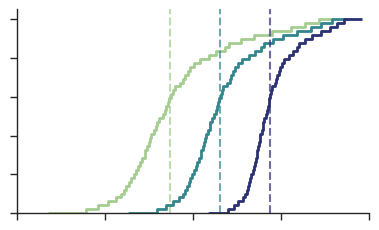

Model L3B: Weighted average CPT = 4.3281
Using data for language: chinese with 500 samples.
Mean margin for rho=0.2: -1.4777
rho=0.2: 5.20% of samples have positive provider margin.
Mean margin for rho=0.4: -0.8583
rho=0.4: 6.40% of samples have positive provider margin.
Mean margin for rho=0.6: -0.2388
rho=0.6: 14.00% of samples have positive provider margin.


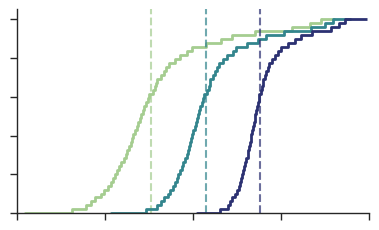

Model G1B: Weighted average CPT = 4.6950
Using data for language: chinese with 500 samples.
Mean margin for rho=0.2: -1.2634
rho=0.2: 6.40% of samples have positive provider margin.
Mean margin for rho=0.4: -0.6975
rho=0.4: 6.60% of samples have positive provider margin.
Mean margin for rho=0.6: -0.1317
rho=0.6: 11.00% of samples have positive provider margin.


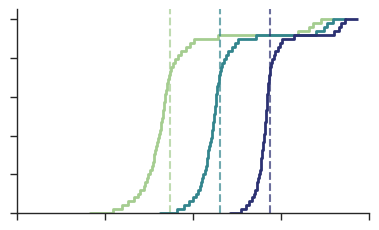

Model G4B: Weighted average CPT = 4.8175
Using data for language: chinese with 500 samples.
Mean margin for rho=0.2: -1.3515
rho=0.2: 4.40% of samples have positive provider margin.
Mean margin for rho=0.4: -0.7636
rho=0.4: 6.00% of samples have positive provider margin.
Mean margin for rho=0.6: -0.1757
rho=0.6: 12.40% of samples have positive provider margin.


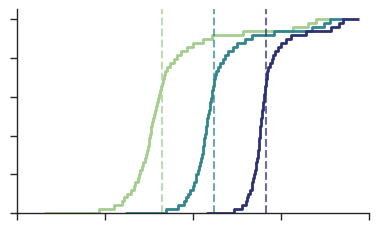

np.float64(4.817450601219707)

In [31]:
from matplotlib.ticker import PercentFormatter


def plot_margin_cdf(short_name, temperature,
                    rho_list=[0.1, 0.3, 0.5, 0.7, 0.9],
                    language="joint", n_steps=100):
    """Step-CDF of the provider's margin distribution for each ``rho``.

    Differs from ``plot_margin_pdf`` in two ways:
    1. Plots a quantile-binned step CDF rather than a KDE.
    2. The reference CPT is the *harmonic* mean of per-output CPT on the
       joint dataset, ``1 / mean(1 / cpt_output)``.

    Saves to ``FIGURES_DIR/margin_dist/``.
    """
    if isinstance(rho_list, float):
        rho_list = [rho_list]
    tokenizer = TOKENIZERS[short_name]

    language_data = {lang: load_factual(short_name, 0.95, temperature, language=lang)
                     for lang in LANGUAGES}

    concatenated_data = []
    for lang in LANGUAGES:
        data = language_data[lang]
        proportion = LANGUAGE_PROPORTIONS[lang]
        total_samples = len(data) * len(data[0]["output"])
        samples_to_take = int(total_samples * proportion / LANGUAGE_PROPORTIONS["english"])
        sample_count = 0
        for prompt_data in data:
            for output in prompt_data["output"]:
                if sample_count < samples_to_take:
                    concatenated_data.append({"language": lang, "output": output,
                                              "prompt": prompt_data["prompt"]})
                    sample_count += 1
                else:
                    break
            if sample_count >= samples_to_take:
                break

    if language == "joint":
        data_to_use = concatenated_data
    elif language in LANGUAGES:
        data_to_use = [{"output": output}
                       for prompt_data in language_data[language]
                       for output in prompt_data["output"]]
    else:
        raise ValueError(f"Unknown language '{language}'.")

    # Reference CPT: harmonic mean of per-output CPT on the joint dataset.
    cpts = []
    for sample in concatenated_data:
        output = sample["output"]
        if len(output) == 0:
            continue
        chars = len(tokenizer.decode(output))
        tokens = len(output)
        if tokens == 0 or chars == 0:
            continue
        cpts.append(1 / (chars / tokens))
    weighted_cpt = 1 / np.mean(cpts)
    print(f"Model {short_name}: Weighted average CPT = {weighted_cpt:.4f}")
    print(f"Using data for language: {language} with {len(data_to_use)} samples.")

    sns.set_theme(context="paper", style="ticks", font_scale=1)
    utils.latexify()
    fig_width, fig_height = utils.get_fig_dim(469, fraction=0.6)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    cmap = sns.color_palette("crest", as_cmap=True)
    colors = [cmap(0.0), cmap(0.5), cmap(1.0)]

    for rho, color in zip(rho_list, colors):
        new_quantity = []
        for sample in data_to_use:
            output = sample["output"]
            if len(output) == 0:
                continue
            chars = len(tokenizer.decode(output))
            tokens = len(output)
            if tokens == 0 or chars == 0:
                continue
            cpt_output = chars / tokens
            new_quantity.append(1 - (weighted_cpt / cpt_output) * (1 - rho))

        q = np.linspace(0, 1, n_steps)
        x = np.quantile(new_quantity, q)
        ax.step(x, q, where="post", color=color, linewidth=2, label=f"rho={rho}")
        ax.hlines(y=1.0, xmin=x[-1], xmax=ax.get_xlim()[1], colors=color, linewidth=2)

        mean_lang = np.mean(new_quantity)
        print(f"Mean margin for rho={rho}: {mean_lang:.4f}")
        ax.axvline(x=mean_lang, color=color, linestyle="--", linewidth=1.5, alpha=0.7)

        pct_positive = sum(1 for v in new_quantity if v > 0) / len(new_quantity) * 100
        print(f"rho={rho}: {pct_positive:.2f}% of samples have positive provider margin.")

    sns.despine(ax=ax)
    ax.set_xticks([-3, -2, -1, 0, 1])
    ax.set_xlim(-3, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    fig.tight_layout()
    plt.show()
    out_path = os.path.join(FIGURES_DIR, "margin_dist",
                            f"cdf_margin_dist_{short_name}_{language}.pdf")
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    fig.savefig(out_path, dpi=300)
    return weighted_cpt


rho_list = [0.2, 0.4, 0.6]
temperature = 1.0
plot_margin_cdf("L1B", temperature, rho_list=rho_list, language="chinese", n_steps=50)
plot_margin_cdf("L3B", temperature, rho_list=rho_list, language="chinese", n_steps=50)
plot_margin_cdf("G1B", temperature, rho_list=rho_list, language="chinese", n_steps=50)
plot_margin_cdf("G4B", temperature, rho_list=rho_list, language="chinese", n_steps=50)
